### PARCIAL PRACTICO

1. (1 punto) Carga el archivo titanic.csv en un DataFrame de Pandas y muestra las primeras 5
 filas. Ademas carga una foto del titanic y de su capitán.

In [9]:
import pandas as pd
import numpy as np


In [10]:
df_titanic = pd.read_csv('/content/titanic.csv')

In [11]:
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


2. (1 punto) Selecciona la columna de edades (Age), elimina los valores nulos y conviértela en
un Array de NumPy. Imprime los primeros 10 valores.


In [28]:
age_column = df_titanic['Age'].dropna()
age_array = age_column.to_numpy()
age_array[:10]

array([22., 38., 26., 35., 35., 54.,  2., 27., 14.,  4.])

3. (1 punto) Convierte la columna de tarifas (Fare) en un array de NumPy y determina su tamaño
(número de elementos).


In [29]:
fare_array = df_titanic['Fare'].to_numpy()
fare_size = fare_array.size
fare_size

891

4. (1 punto) Crea un nuevo DataFrame (llamado df_filtrado) que contenga únicamente las
columnas: Survived, Pclass, Sex, Age y Fare.

In [18]:
df_filtrado = df_titanic[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

In [19]:
df_filtrado

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500
...,...,...,...,...,...
886,0,2,male,27.0,13.0000
887,1,1,female,19.0,30.0000
888,0,3,female,NaN,23.4500
889,1,1,male,26.0,30.0000


5. (1 punto) Calcula la media (promedio) de la edad de los pasajeros.

In [21]:
df_titanic['Age'].mean()

np.float64(29.69911764705882)

6. (1 punto) Encuentra la mediana de la tarifa (Fare) pagada por los pasajeros.

In [27]:
df_titanic['Fare'].median()

14.4542

7. (1 punto) Determina la moda de la clase de los pasajeros (Pclass).

In [35]:
df_titanic['Pclass'].mode()

,Pclass
0,3


8. (1 punto) Utilizando el array de NumPy de edades creado en el punto 2, calcula la media y la
mediana usando exclusivamente funciones de la librería numpy.


In [38]:
age_mean_np = np.mean(age_array)
age_median_np = np.median(age_array)

age_mean_np

np.float64(29.69911764705882)

In [39]:
age_median_np

np.float64(28.0)

9. (1 punto) Agrupa los datos por la clase del pasajero (Pclass) y calcula la tarifa promedio para
cada clase. Analiza el resultado con sus propias palabras.

In [44]:
pclass = df_titanic.groupby('Pclass')['Fare'].mean()
pclass


,Fare
Pclass,
1,84.154687
2,20.662183
3,13.675550


Podemos observar que la tarifa promedio disminuye a medida que la clase del apsajero aumenta (Primera, Segunda y Tercera Clase). Esto es esperado, ya que la Primera Clase es la más lujosa y por ende la más cara, mientras que la Tercera Clase es la más económica.

10. (1 punto) Utiliza groupby para encontrar la edad promedio separada por hombres y mujeres
(Sex). Analiza el resultado con sus propias palabras.

In [45]:
age = df_titanic.groupby('Sex')['Age'].mean()
age

,Age
Sex,
female,27.915709
male,30.726645


Se observa que analizando el promedio de edad, las mujeres que estaban a abordo son más jovenes que los hombres.

11. (1 punto) Agrupa por la columna Survived y cuenta cuántos pasajeros sobrevivieron (1) y
cuántos no (0). Analiza el resultado con sus propias palabras.

In [47]:
survived = df_titanic.groupby('Survived').size()
survived

,0
Survived,
0,549
1,342


Se denota que las debido al accidente ocurrido en el Titanic, en promedio fallecieron más personas que las que sobrevivieron.

12. (1 punto) Realiza una agrupación múltiple por clase (Pclass) y sexo (Sex), y calcula la
mediana de la edad (Age) para cada subgrupo.

In [49]:
median_age = df_titanic.groupby(['Pclass', 'Sex'])['Age'].median()
median_age

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

13. (1 punto) Crea una tabla cruzada (pd.crosstab) que muestre la cantidad de hombres y mujeres
que sobrevivieron y los que no. Analiza el resultado con sus propias palabras.

In [51]:
sex_survived = pd.crosstab(df_titanic['Sex'], df_titanic['Survived'])
sex_survived

Survived,0,1
Sex,,
female,81,233
male,468,109


En la tabla muestra que un número siginificativo de mujeres sobrevivio a compración de los hombres, esto sugiere que los niños y las mujeres tuvieron prioridad en los botes salvavidas

---



14. (1 punto) Genera una tabla pivote (pivot_table) que muestre el promedio de la tarifa (Fare)
pagada según la clase (Pclass) en las filas, y el puerto de embarque (Embarked) en las
columnas.

In [53]:
pivot_table_fare = df_titanic.pivot_table(values='Fare', index='Pclass', columns='Embarked', aggfunc='mean')
pivot_table_fare

Embarked,C,Q,S
Pclass,,,
1,104.718529,90.000000,70.364862
2,25.358335,12.350000,20.327439
3,11.214083,11.183393,14.644083


15. (1 punto) Crea una tabla que muestre la proporción (porcentaje) de supervivencia por cada
clase (Pclass).


In [56]:
survival_by_pclass = df_titanic.groupby('Pclass')['Survived'].value_counts(normalize=True).unstack()
survival_by_pclass['Survival_Percentage'] = survival_by_pclass[1] * 100 # Assuming 1 is 'Survived'
survival_by_pclass[['Survival_Percentage']]

Survived,Survival_Percentage
Pclass,
1,62.962963
2,47.282609
3,24.236253


16. (1 punto) Muestra una tabla que resuma la cantidad de valores nulos (vacíos) que tiene cada
columna del DataFrame original.


In [57]:
df_titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


17. (1 punto) Crea un gráfico de pastel que muestre la proporción de hombres y mujeres a bordo
del Titanic. Analiza el resultado con sus propias palabras.

In [59]:
import matplotlib.pyplot as plt

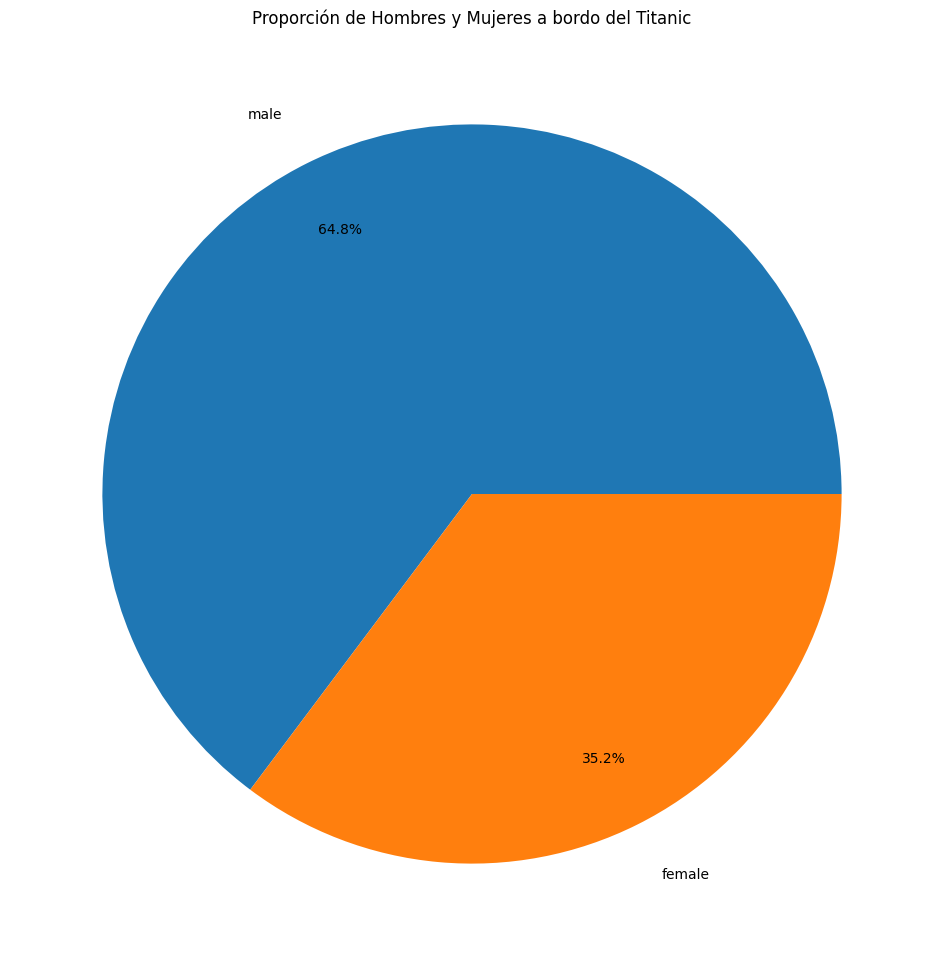

In [64]:
plt.figure(figsize=(12,12))

plt.pie(
    sex_counts,
    labels=sex_counts.index,
    autopct='%1.1f%%',
    pctdistance=0.8,
    labeldistance=1.15
)

plt.title('Proporción de Hombres y Mujeres a bordo del Titanic')
plt.show()

Se puede observar que hay una mayor proporción de hombres (aproximadamente un 64.8%) en comparación con las mujeres (alrededor de un 35.2%). Esto indica que la mayoría de los pasajeros eran hombres.

18. (1 punto) Realiza un gráfico de pastel para visualizar qué porcentaje de pasajeros viajaba en
cada una de las 3 clases (Pclass). Analiza el resultado con sus propias palabras.

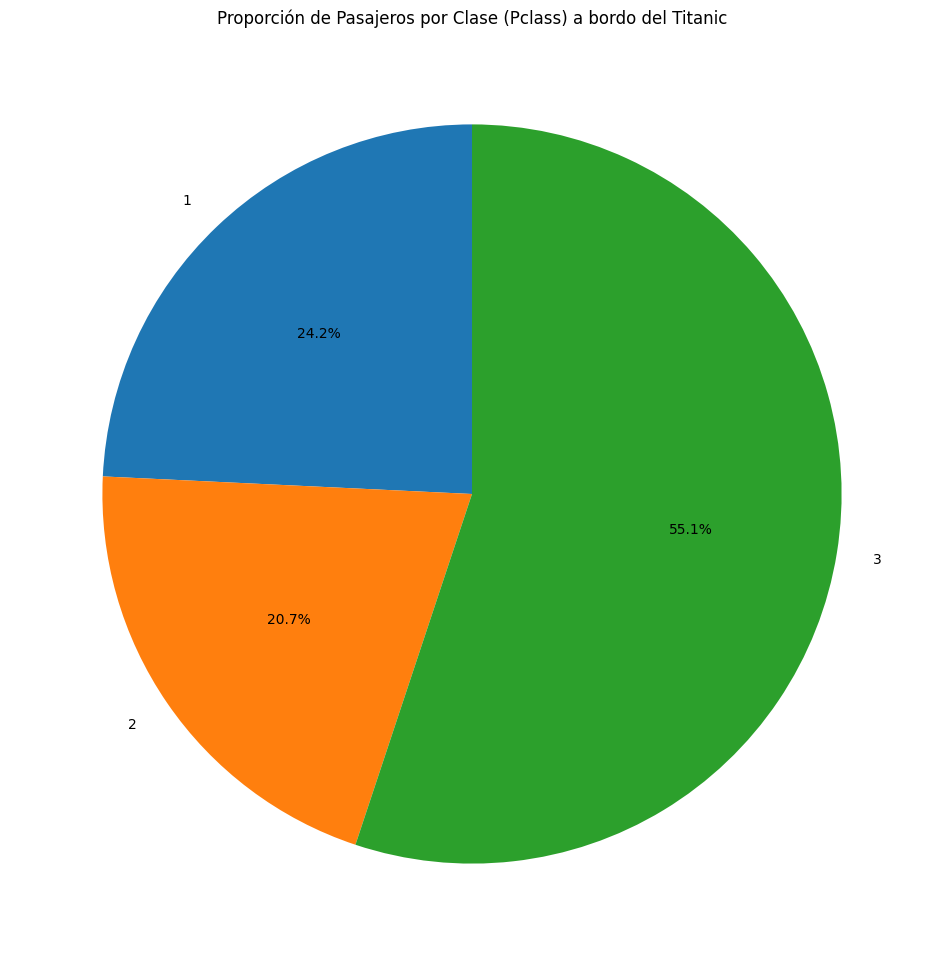

In [67]:
pclass_counts = df_titanic['Pclass'].value_counts().sort_index()

plt.figure(figsize=(12,12))
plt.pie(pclass_counts,
        labels=pclass_counts.index,
        autopct='%1.1f%%',
        startangle=90)
plt.title('Proporción de Pasajeros por Clase (Pclass) a bordo del Titanic')
plt.show()

Se puede observar que la clase 3 es la que tenía mayor cantidad de pasajeros a bordo 55.1% siendo costa la más economica, la clase 1 es la segunda con un 24,% y la clase 2 con menos pasajeros 20.7%. Esto denota que la mayoría de pasajeron que viajaban en el Titanic es de la clase económica.

19. (1 punto) Muestra en un gráfico de pastel el porcentaje total de pasajeros que sobrevivieron
contra los que no sobrevivieron. Analiza el resultado con sus propias palabras.


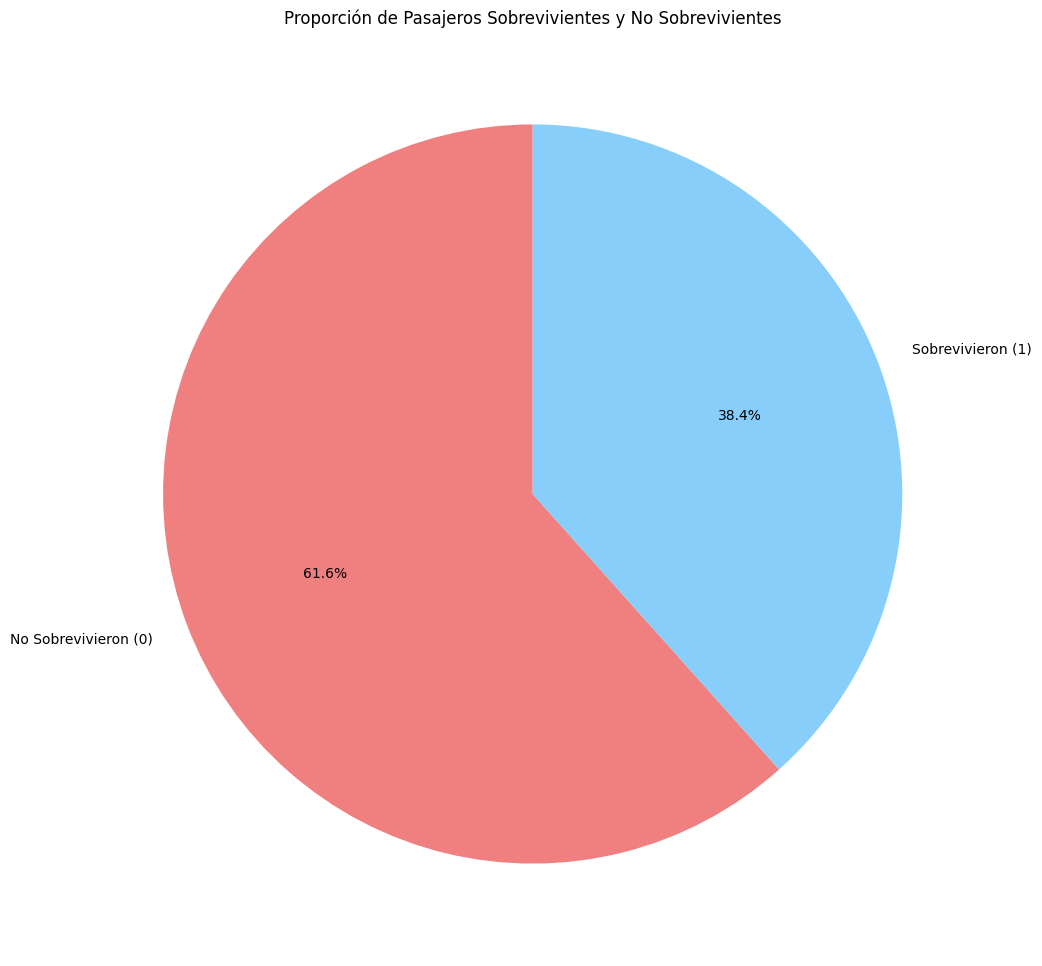

In [69]:
survived_counts = df_titanic['Survived'].value_counts()

plt.figure(figsize=(12, 12))
plt.pie(survived_counts,
        labels=['No Sobrevivieron (0)', 'Sobrevivieron (1)'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['lightcoral', 'lightskyblue'])
plt.title('Proporción de Pasajeros Sobrevivientes y No Sobrevivientes')
plt.show()

Del gráfico de pastel se puede observar que la mayoría de los pasajeros no sobrevivieron al desastre del Titanic, representando un 61.6%del total. Por otro lado, el 38.4% de los pasajeros sí logró sobrevivir.

20. (1 punto) Genera un gráfico de pastel mostrando la proporción de pasajeros según la ciudad
donde embarcaron (Embarked: C, Q, S).

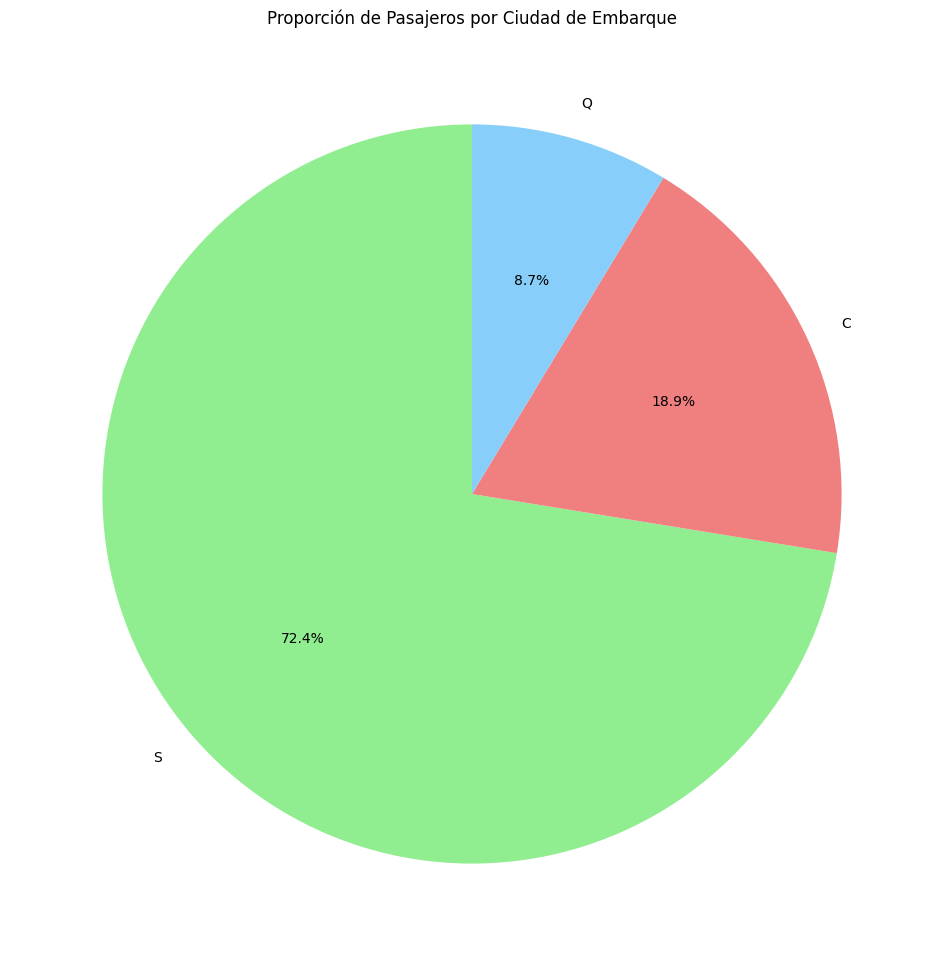

In [71]:
embarked_counts = df_titanic['Embarked'].value_counts()

plt.figure(figsize=(12, 12))
plt.pie(embarked_counts,
        labels=embarked_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['lightgreen', 'lightcoral', 'lightskyblue'])
plt.title('Proporción de Pasajeros por Ciudad de Embarque')
plt.show()

Se observa que la mayoría de pasajeros que embarcaron el Titanic fue en la ciudad de Southampton (S) con un 72.4%, segundo por Cherbourg (C) con un 18.9% y finalmente Queenstown (Q) con un 8.6%.

Foto del Titanic

[texto del enlace](https://www.worldhistory.org/uploads/images/14047.png)

Foto del Capitan del Titanic

[texto del enlace](https://cloudfront-us-east-1.images.arcpublishing.com/infobae/HJRHQVKOB5BI7D5V7KSLSGY774.jpg)